# FOR THIS PROJECT I WILL USE THE INSTRUCTIONS PRESENTS ON HAND-ON-IN MACHINE LEARNING WITH SCIKIT LEARN.... BY AURÉLION GERON

**THIS IS THE 2 CHAPTER, AND MY FIRST MACHINE LEARNING PROJECT, ILL DO THAT WITH BOOKS LEARNING, AND MY KNOWLEDGE ABOUT THE THEME**

### 1. ANALYZE THE SITUAION
**QUESTIONS**
- What's the real problem? -> The prices of houses in California it's calculate manually fro researches, and costs it money and time, so we gonna need to do a model to improve that

- What's the final objective? -> We need to predict the 'price values' of the houses, so we gonna use PREDICT objective.

- How the model will be used? -> The model will be used like an app (in this case a terminal it's ok), and we gonna use a old dataset, without new data, so it's once a time train

- The model have restrictions? -> No.

- In the future, the problem will be changed? -> No.

- In the futur, new data will come? No.

- Define the system os ml project -> (A: Supevised, B: batch (offline), C: modules, D: to define yet, E: to define yet, F: to define yet)


In [11]:
import pandas as pd

df = pd.read_csv('../../datasets/housing.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [12]:
df.dropna(inplace = True)

In [13]:
df['ocean_proximity'] = df['ocean_proximity'].astype('category').cat.codes
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,1
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,1
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,1
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,1


In [14]:
df['longitude'] = df['longitude'].abs()
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3
...,...,...,...,...,...,...,...,...,...,...
20635,121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,1
20636,121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,1
20637,121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,1
20638,121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,1


In [15]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155,1.166153
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099,1.420135
min,114.310000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.000000
25%,118.010000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000,0.000000
50%,118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000,1.000000
75%,121.800000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000,1.000000
max,124.350000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,4.000000


--------------------------------------------
MODEL: LinearRegression()
The accuracy in validation set it's: R2: 63.60%, mae:50630.497
The accuracy of in test set it's: R2: 63.99%, mae:51388.700


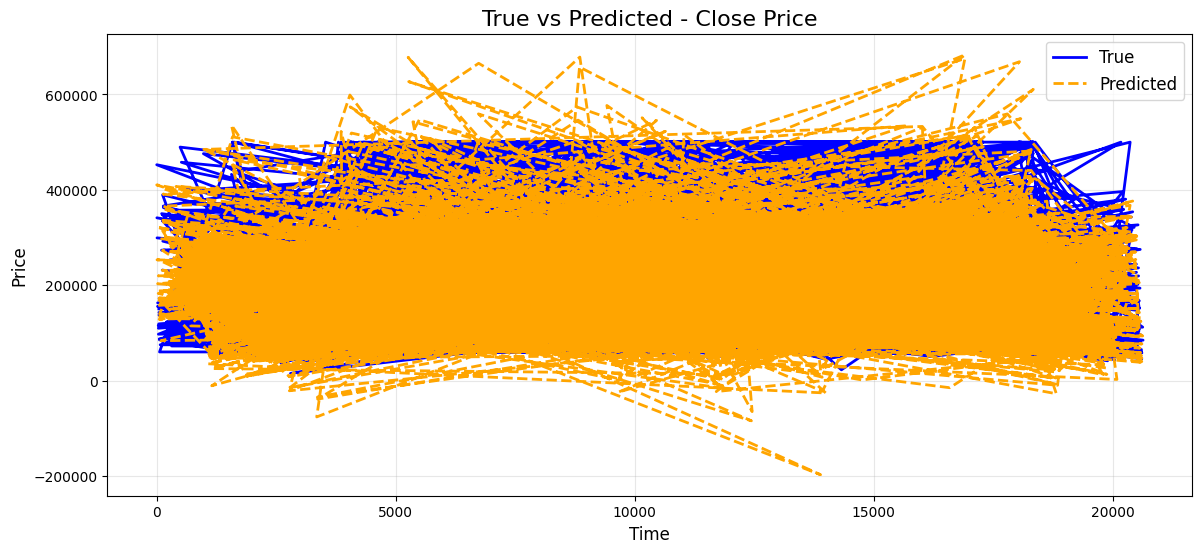

--------------------------------------------
MODEL: Ridge()
The accuracy in validation set it's: R2: 63.60%, mae:50630.440
The accuracy of in test set it's: R2: 63.99%, mae:51388.597


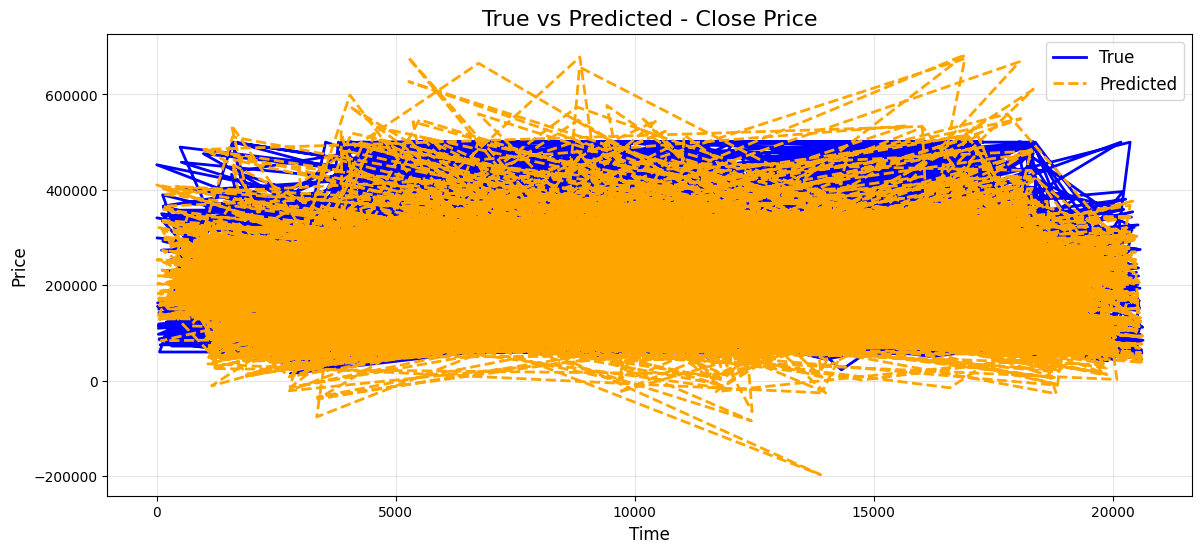

--------------------------------------------
MODEL: Lasso()
The accuracy in validation set it's: R2: 63.60%, mae:50630.666
The accuracy of in test set it's: R2: 63.99%, mae:51388.826


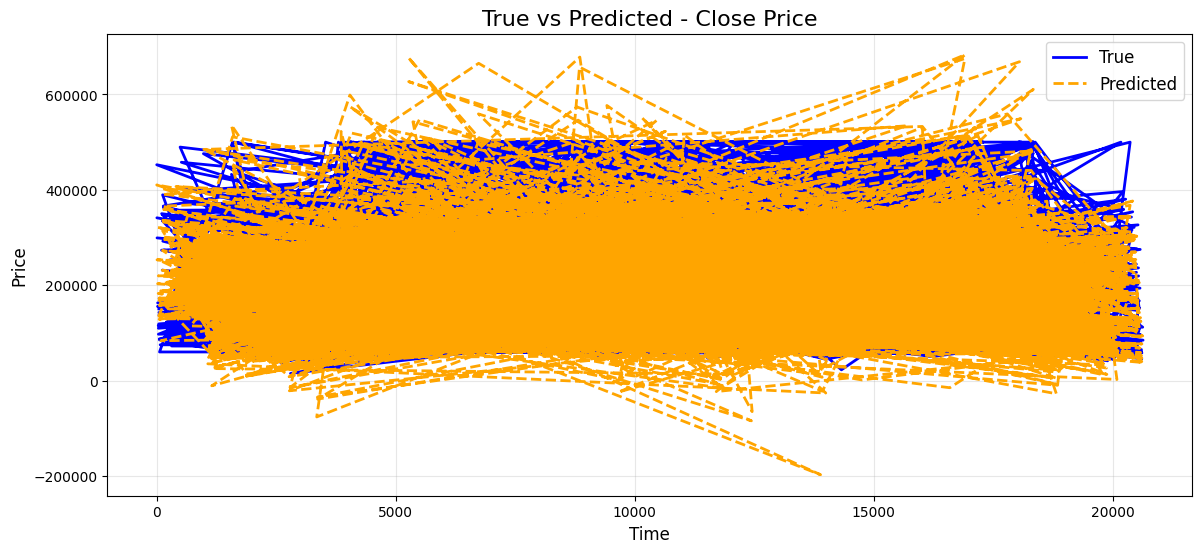

--------------------------------------------
MODEL: ElasticNet()
The accuracy in validation set it's: R2: 49.61%, mae:62450.718
The accuracy of in test set it's: R2: 49.49%, mae:63873.134


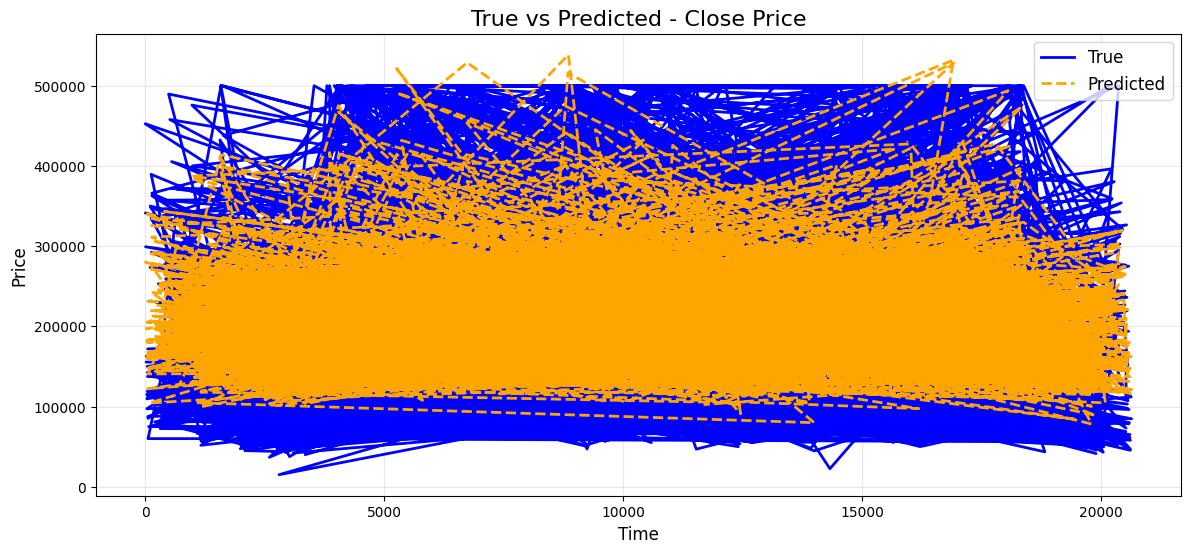

In [18]:
# SCALER, AND ALL MDOELS

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# GET THE DATA
X = df.drop('median_house_value', axis = 1)
y = df[['median_house_value']]

# SPLIT THE DATA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# GET THE MODELS
models_linear = [LinearRegression(), Ridge(), Lasso(), ElasticNet()]

# GET THE PIPE LINE
for model in models_linear:
        print('--------------------------------------------')
        print(f"MODEL: {model}")

        pipe = Pipeline(
                steps=[
                ('Scaler', StandardScaler()),
                ("Model", model)
                ]
        )
        # TRAIN THE MODEL
        pipe.fit(X_train, y_train)

        # SEE THE ACCURACY OF THE TRAIN
        y_preds_train = pipe.predict(X_train)
        r2 = r2_score(y_train, y_preds_train)
        mae = mean_absolute_error(y_train, y_preds_train)
        print(F"The accuracy in validation set it's: R2: {r2*100:.2f}%, mae:{mae:.3f}")


        # SEE THE ACCURACY OF THE TEST
        y_preds_test = pipe.predict(X_test)
        r2 = r2_score(y_test, y_preds_test)
        mae = mean_absolute_error(y_test, y_preds_test)
        print(F"The accuracy of in test set it's: R2: {r2*100:.2f}%, mae:{mae:.3f}")

        plt.figure(figsize=(14,6))
        plt.plot(y_test.index, y_test.values, label='True', color='blue', linewidth=2)
        plt.plot(y_test.index, y_preds_test, label='Predicted', color='orange', linestyle='--', linewidth=2)
        plt.title("True vs Predicted - Close Price", fontsize=16)
        plt.xlabel("Time", fontsize=12)
        plt.ylabel("Price", fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=12)
        plt.show()



--------------------------------------------
MODEL: DecisionTreeRegressor(max_depth=10)
The accuracy in validation set it's: R2: 84.28%, mae:30483.878
The accuracy of in test set it's: R2: 72.20%, mae:40077.510


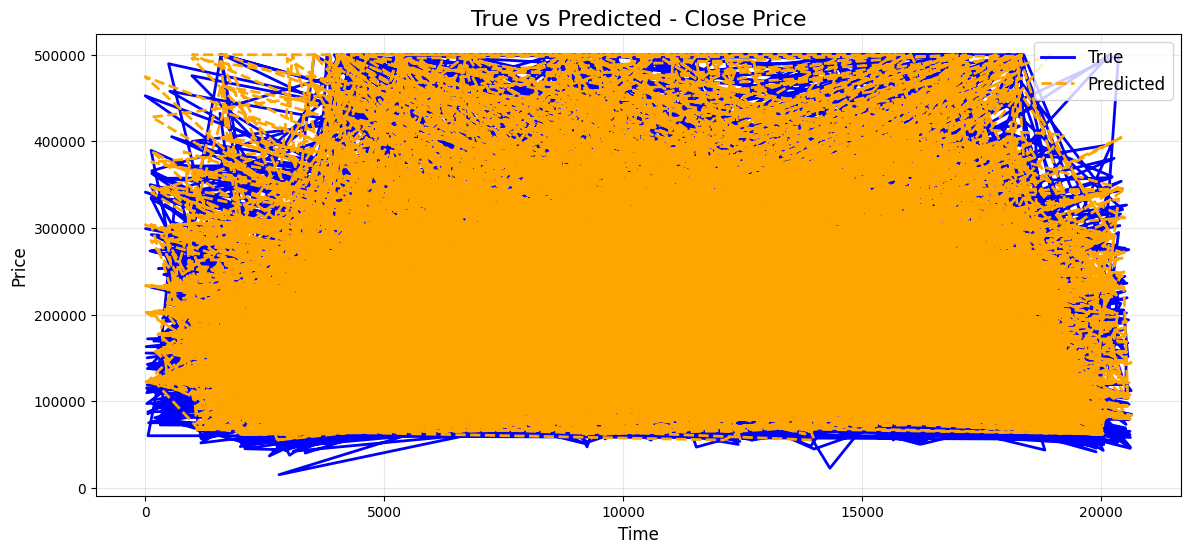

--------------------------------------------
MODEL: RandomForestRegressor(n_estimators=150)


c:\Users\tevos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


The accuracy in validation set it's: R2: 97.46%, mae:11767.146
The accuracy of in test set it's: R2: 82.09%, mae:32029.003


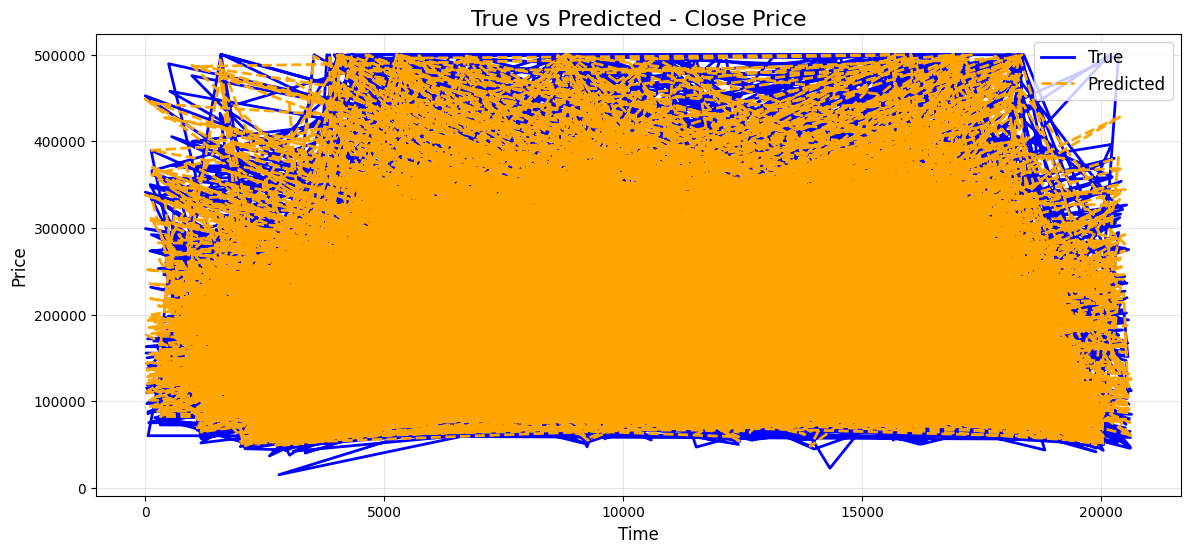

--------------------------------------------
MODEL: KNeighborsRegressor()
The accuracy in validation set it's: R2: 81.51%, mae:33082.669
The accuracy of in test set it's: R2: 71.58%, mae:41316.989


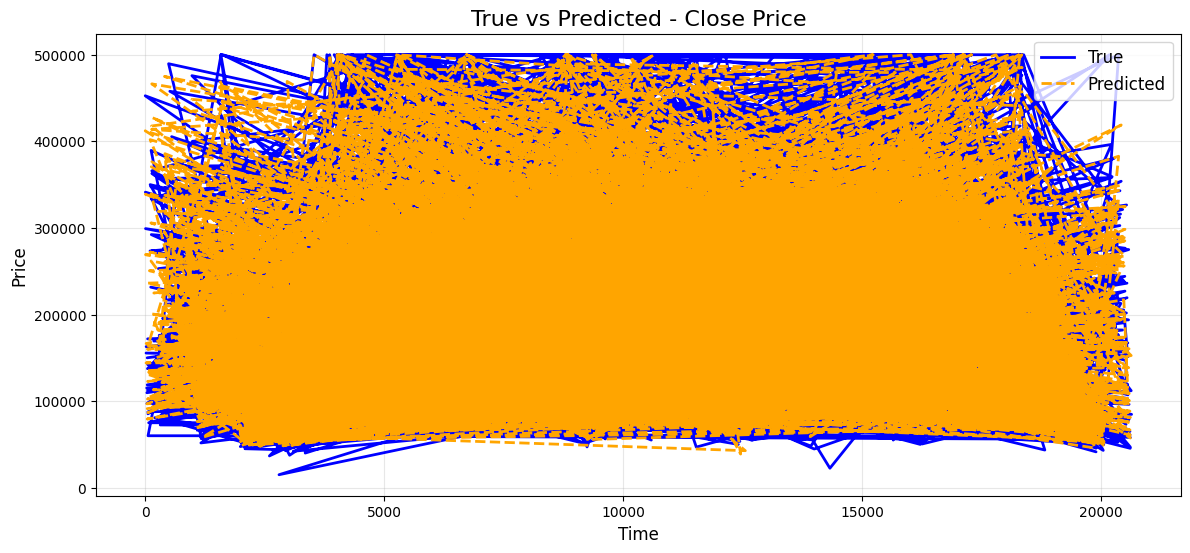

In [19]:
DecisionTreeRegressor(), RandomForestRegressor(), KNeighborsRegressor()

models_nongradient = [DecisionTreeRegressor(max_depth = 10), RandomForestRegressor(n_estimators = 150), KNeighborsRegressor()]

# GET THE PIPE LINE
for model in models_nongradient:
        print('--------------------------------------------')
        print(f"MODEL: {model}")

        pipe = Pipeline(
                steps=[
                ('Scaler', StandardScaler()),
                ("Model", model)
                ]
        )
        # TRAIN THE MODEL
        pipe.fit(X_train, y_train)

        # SEE THE ACCURACY OF THE TRAIN
        y_preds_train = pipe.predict(X_train)
        r2 = r2_score(y_train, y_preds_train)
        mae = mean_absolute_error(y_train, y_preds_train)
        print(F"The accuracy in validation set it's: R2: {r2*100:.2f}%, mae:{mae:.3f}")


        # SEE THE ACCURACY OF THE TEST
        y_preds_test = pipe.predict(X_test)
        r2 = r2_score(y_test, y_preds_test)
        mae = mean_absolute_error(y_test, y_preds_test)
        print(F"The accuracy of in test set it's: R2: {r2*100:.2f}%, mae:{mae:.3f}")

        plt.figure(figsize=(14,6))
        plt.plot(y_test.index, y_test.values, label='True', color='blue', linewidth=2)
        plt.plot(y_test.index, y_preds_test, label='Predicted', color='orange', linestyle='--', linewidth=2)
        plt.title("True vs Predicted - Close Price", fontsize=16)
        plt.xlabel("Time", fontsize=12)
        plt.ylabel("Price", fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=12)
        plt.show()
